### 加载数据

In [43]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio import RiskMeasure, PerfMeasure, RatioMeasure
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
from synthetic_returns import estimate_marginal_stats, synthesize_returns
set_config(transform_output="pandas")
init_logger("WF_CPCV_PS_252")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\WF_CPCV_PS_252.log


In [2]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2141 只 | 2604 天 | 2016-01-04 ~ 2026-09-18
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2603 天 x 2137 资产 | 列集一致: True


In [3]:
#stats  = estimate_marginal_stats(X)                        # ① 逐标的统计属性 + 拟合参数表
#X_fake = synthesize_returns(X, random_state=42)            # ② 默认 student_t + 保留截面相关
#X_fake, report = synthesize_returns(X, random_state=42, return_report=True)
X_ctrl = synthesize_returns(X, distribution="gaussian")    # 高斯对照项
X_fake = synthesize_returns(X, random_state=42)

硬截断告警：5 列截断比例超过阈值（最高 512420.SH: 截断 13.33% / 阈值 19.35% / 样本 30）
硬截断告警：1 列截断比例超过阈值（最高 520740.SH: 截断 10.34% / 阈值 20.00% / 样本 29）


### 参数搜索
- Walkforward:
    - CombinatorialPurgedCV

In [26]:
from wf_cpcv_search import load_nested_config
from cpcv_search_base import build_pipeline_src
from walkforward_parameter_search import compute_grid_size
from wf_cpcv_search import nested_adaptive_search, adaptive_multi_paths, build_test_parts, summarize_fold_params,summarize_top_k_params
from cpcv_analysis import discrete_lhs_safe, diagnose_oos_lhs, report_ann_distribution, turnover_series
from cpcv_analysis import plot_oos_vs_bench,excess_vs_bench, plot_paths_curve, rank_pbo_logit
from wf_cpcv_robustness import (perturbation_mc, sensitivity_curves, sensitivity_heatmap, topk_paths_eval,)
from wf_cpcv_ablation import ablate

In [44]:
log_print("mean(Annualized Sharpe Ratio)/2 - mean(MAXDD) + mean(SKEW)", section='Ojective', echo=False)
log_print(build_pipeline_src(), section="Model Pipeline", echo=False)

In [48]:
search_space = {'nondomin__min_n_assets': {'low': 20, 'high': 55, 'step': 5},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.3, 'step': 0.1},
 'extremes__k': {'low': 0.5, 'high': 0.9, 'step': 0.1},
 'nondomin__fitness_measures': [
    "mean-variance-kurt",
    "mean-variance-maxdd-kurt",
    "mean-variance-avgdd-kurt",
    #"mean-semideviation-avgdd",
    #"mean-mad-maxdd-kurt",
    #"mean-mad-avgdd-kurt",
    "mean-mad-maxdd-cvar-kurt",
    "mean-mad-maxdd-cvar-sharpe",
    "mean-mad-avgdd-cvar-kurt",
    "mean-mad-avgdd-cvar-sharpe",
    ],
 'train_size': {'low': 252, 'high': 756, 'step': 252}}  # inner train size
log_print(search_space, section='Parameter Space', echo=False)
log_print(compute_grid_size(search_space), section='Parameter Count', echo=True)

7560


In [ ]:
search_params = {'test_size': 252,
  'train_size': 756+252,
  'n_test_folds': 2,
  'n_jobs': 4,
  'cv_n_jobs': 6,
  'n_trials': 2000,
  'patience': 200,
  'sampler': 'tpe',
  'min_delta': 0.0001,
  'outer_purged_size': 0,
  'outer_reduce_test': False,
  'seed': 42,
  'verbose': True}
log_print(search_params, section="Search Parameter", echo=False)

In [49]:
# 386177
#X = X.tail(search_params['train_size'] + search_params['test_size'] + 1).copy()
fold_real = nested_adaptive_search(X,space=search_space, **search_params)

  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 0: mean score=0.8537 | test_ann=0.1130 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 1: mean score=0.9284 | test_ann=0.0654 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

...

Fold 3: mean score=0.7145 | test_ann=0.0691 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 4: mean score=1.3048 | test_ann=0.1799 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 5: mean score=0.3201 | test_ann=0.1690 | test_days=252


In [ ]:
fold_fake = nested_adaptive_search(X_fake,space=search_space, **search_params)

In [ ]:
fold_ctrl = nested_adaptive_search(X_ctrl,space=search_space, **search_params)

#### Train vs Test

In [50]:
train_population = Population([result['train'] for result in fold_real])
test_population = Population([result['test'] for result in fold_real])
train_population.set_portfolio_params(tag="Train")
test_population.set_portfolio_params(tag="Test")
population = train_population + test_population
population.plot_measures(
    x=RiskMeasure.ANNUALIZED_STANDARD_DEVIATION,
    y=PerfMeasure.ANNUALIZED_MEAN,
    color_scale=RatioMeasure.ANNUALIZED_SHARPE_RATIO,
    hover_measures=[RiskMeasure.MAX_DRAWDOWN, RatioMeasure.ANNUALIZED_SORTINO_RATIO],
)

### Step 1 | IS 审计：每折 P Luck + Top-K 候选
- dsr = 该折最优分数超过"纯运气挑最优"基准的经验概率（H0 噪声 MC deflate，N = 参数去重后的真实试验数）。 margin = sr_obs − E[max_N]，max_p95 为运气基准 95% 分位。
- gap2top1（summarize_top_k_params 的列）= IS 侧 top1 与 top2 的分数落差： 落差小 → 参数处在平台（好信号）；落差大 → top1 可能是运气孤峰（坏信号）。

In [51]:
log_print(summarize_fold_params(fold_real).to_string(),section='Best Parameter', echo=True)

   fold   score  p_luck  margin  train ASR  test ASR  nondomin__min_n_assets  nondomin__threshold  correlate__threshold  extremes__k  train_size                     fitness  n_trials
0     0  0.8537  0.9377 -0.0663     1.9251    1.0364                      20                 -0.4                   0.1          0.8         252    mean-mad-avgdd-cvar-kurt        86
1     1  0.9284  0.7109 -0.0615     2.1546    0.9188                      50                 -0.4                   0.2          0.6         252  mean-mad-maxdd-cvar-sharpe        94
2     2  0.5468  0.8838 -0.1006     1.5098    0.2923                      55                 -0.4                   0.1          0.7         504  mean-mad-maxdd-cvar-sharpe        62
3     3  0.7145  0.8399 -0.0705     1.2703    1.4719                      40                 -0.3                   0.1          0.9         504  mean-mad-avgdd-cvar-sharpe        67
4     4  1.3048  0.8037 -0.1437     0.7223    1.5844                      40         

In [52]:
out = rank_pbo_logit(X, fold_real, purged_size=0, reduce_test=False)

Fold 0: N=86 | w_train=0.84 | w_test=0.45 | lambda_test=-0.18
Fold 1: N=94 | w_train=0.74 | w_test=0.62 | lambda_test=+0.49
Fold 2: N=62 | w_train=0.57 | w_test=0.22 | lambda_test=-1.25
Fold 3: N=67 | w_train=0.53 | w_test=0.47 | lambda_test=-0.12
Fold 4: N=78 | w_train=0.87 | w_test=0.44 | lambda_test=-0.23
Fold 5: N=61 | w_train=0.78 | w_test=0.04 | lambda_test=-3.17

        CPCV 选择排名 PBO 诊断（全参数 train/test 重放）
  折数=6 | 每折参数池 61~94（unique 去重）
  [研究对象1] CPCV-best（路径均值最优；与 train 高度重合，w_train 预期偏高）
    w_train  : 中位 0.76 | 5%~95% [0.54, 0.87] | >0.5 折占比 100%
    lambda_train > 0 折占比 100%
    w_test   : 中位 0.45 | 5%~95% [0.09, 0.58]
    PBO_test = freq(lambda_test < 0) = 83.3% （5/6）
  [研究对象2] train-argmax 对照（标准 CSCV 定义：IS 最优）
    与 CPCV-best 同参折占比 0% | lambda_test 中位 +1.89
    PBO_test(标准) = 0.0% （0/6）
------------------------------------------------------------
  重放校验 max|ΔASR| = 0.00e+00（应≈0；不一致会直接报错）


In [53]:
topk = summarize_top_k_params(fold_real, k=5)         # 行 = (fold, rank)
print(topk[topk["rank"] <= 5][['fold','rank','score','gap2top1']])                    # 每折 top1/top2 候选 + gap2top1

    fold  rank   score  gap2top1
0      0     1  0.8537    0.0000
1      0     2  0.8469    0.0068
2      0     3  0.8469    0.0068
3      0     4  0.8459    0.0078
4      0     5  0.8289    0.0248
5      1     1  0.9284    0.0000
6      1     2  0.9284    0.0000
7      1     3  0.9151    0.0134
8      1     4  0.8957    0.0327
9      1     5  0.8957    0.0327
10     2     1  0.5468    0.0000
11     2     2  0.5468    0.0000
12     2     3  0.5336    0.0132
13     2     4  0.5329    0.0139
14     2     5  0.5303    0.0166
15     3     1  0.7145    0.0000
16     3     2  0.7059    0.0086
17     3     3  0.7010    0.0135
18     3     4  0.7010    0.0135
19     3     5  0.6694    0.0451
20     4     1  1.3048    0.0000
21     4     2  1.2062    0.0986
22     4     3  1.2062    0.0986
23     4     4  1.2062    0.0986
24     4     5  1.1764    0.1284
25     5     1  0.3201    0.0000
26     5     2  0.2976    0.0225
27     5     3  0.2975    0.0227
28     5     4  0.2904    0.0297
29     5  

### Step 2｜过拟合判据：DSR 低 + OOS 衰减
- 判据：WFE > 0.5 为稳健泛化（多数折满足）。
- "DSR 低 + OOS 显著下降" = 内层选择偏差校正后无真实优势 + 样本外掉队 → 该折结论不可信，

In [55]:
df = summarize_fold_params(fold_real).copy()
df["WFE"] = df["test ASR"] / df["train ASR"]      # 每折 IS→OOS 衰减比
df["flag"] = (df["p_luck"] > 0.5) & (df["WFE"] < 0.5)   # 运气嫌疑高 + 衰减 = 过拟合嫌疑折
print(df[["fold", "p_luck", "train ASR", "test ASR", "WFE", "flag"]])

   fold  p_luck  train ASR  test ASR       WFE   flag
0     0  0.9377     1.9251    1.0364  0.538362  False
1     1  0.7109     2.1546    0.9188  0.426436   True
2     2  0.8838     1.5098    0.2923  0.193602   True
3     3  0.8399     1.2703    1.4719  1.158703  False
4     4  0.8037     0.7223    1.5844  2.193548  False
5     5  0.7475     1.2117    1.8458  1.523314  False


### Step 3｜Top-K 候选 OOS 多路径压测
- 窗口自动从 folds 推导（折位 1:1）；如需 notebook 原压测口径（如 `n_test_folds=4`），
  以显式键传入：`topk_paths_eval(X, folds, paths_kwargs={"n_test_folds": 4})`。
- 价值在**参数高原的 OOS 侧印证**：gap2top1 小的候选若 OOS 同样接近，说明生产参数处在稳定平台。

In [60]:
eval_real = topk_paths_eval(X, fold_real, k=10)            # 每折 top1~5 全部进 CPCV 多路径压测

rank1: 完整OOS路径 | 6 折拼接 | 1512 天
rank2: 完整OOS路径 | 6 折拼接 | 1512 天
rank3: 完整OOS路径 | 6 折拼接 | 1512 天
rank4: 完整OOS路径 | 6 折拼接 | 1512 天
rank5: 完整OOS路径 | 6 折拼接 | 1512 天
rank6: 完整OOS路径 | 6 折拼接 | 1512 天
rank7: 完整OOS路径 | 6 折拼接 | 1512 天
rank8: 完整OOS路径 | 6 折拼接 | 1512 天
rank9: 完整OOS路径 | 6 折拼接 | 1512 天
rank10: 完整OOS路径 | 6 折拼接 | 1512 天


In [62]:
eval_fake = topk_paths_eval(X_fake, fold_real, k=10)            # 每折 top1~5 全部进 CPCV 多路径压测

rank1: 完整OOS路径 | 6 折拼接 | 1512 天
rank2: 完整OOS路径 | 6 折拼接 | 1512 天
rank3: 完整OOS路径 | 6 折拼接 | 1512 天
rank4: 完整OOS路径 | 6 折拼接 | 1512 天
rank5: 完整OOS路径 | 6 折拼接 | 1512 天
rank6: 完整OOS路径 | 6 折拼接 | 1512 天
rank7: 完整OOS路径 | 6 折拼接 | 1512 天
rank8: 完整OOS路径 | 6 折拼接 | 1512 天
rank9: 完整OOS路径 | 6 折拼接 | 1512 天
rank10: 完整OOS路径 | 6 折拼接 | 1512 天


In [61]:
eval_ctrl = topk_paths_eval(X_ctrl, fold_real, k=10)            # 每折 top1~5 全部进 CPCV 多路径压测

rank1: 完整OOS路径 | 6 折拼接 | 1512 天
rank2: 完整OOS路径 | 6 折拼接 | 1512 天
rank3: 完整OOS路径 | 6 折拼接 | 1512 天
rank4: 完整OOS路径 | 6 折拼接 | 1512 天
rank5: 完整OOS路径 | 6 折拼接 | 1512 天
rank6: 完整OOS路径 | 6 折拼接 | 1512 天
rank7: 完整OOS路径 | 6 折拼接 | 1512 天
rank8: 完整OOS路径 | 6 折拼接 | 1512 天
rank9: 完整OOS路径 | 6 折拼接 | 1512 天
rank10: 完整OOS路径 | 6 折拼接 | 1512 天


In [63]:
real_paths = eval_real["paths"]     
fake_paths = eval_fake["paths"]      
ctrl_paths = eval_ctrl["paths"]                 # MultiIndex (fold, rank, path)
#audit = eval_["audit"]                            # IS 侧审计，与 paths 按 (fold, rank) 对齐

In [64]:
log_print(real_paths, section="Top 10 参数组合OOS:ASR,MEAN,MAXDD")

      annualized_sharpe_ratio  annualized_mean  max_drawdown
rank                                                        
1                    1.192649         0.105460      0.100100
2                    0.970088         0.083627      0.100763
3                    1.082993         0.105491      0.129153
4                    1.004804         0.095526      0.129153
5                    1.070911         0.108879      0.129153
6                    1.294680         0.119531      0.093607
7                    1.346944         0.129374      0.129153
8                    1.238136         0.114113      0.129153
9                    0.757789         0.067023      0.134883
10                   1.198946         0.110605      0.091573


In [ ]:
log_print(fake_paths, section="Top 10 参数组合OOS:ASR,MEAN,MAXDD(合成数据T分布)")

      annualized_sharpe_ratio  annualized_mean  max_drawdown
rank                                                        
1                    0.878621         0.042321      0.050873
2                    0.823517         0.038596      0.069404
3                    1.014468         0.049419      0.048844
4                    0.602801         0.029564      0.057664
5                    0.585776         0.028129      0.048844
6                    1.009973         0.047424      0.054018
7                    0.733267         0.034671      0.050873
8                    0.792164         0.040865      0.060993
9                    0.662952         0.023216      0.104158
10                   0.020558         0.000814      0.149092


In [66]:
log_print(ctrl_paths, section="Top 10 参数组合OOS:ASR,MEAN,MAXDD(合成数据高斯分布)")

      annualized_sharpe_ratio  annualized_mean  max_drawdown
rank                                                        
1                    0.764587         0.030010      0.044809
2                    0.495143         0.018048      0.076206
3                    0.805272         0.030673      0.044809
4                    1.083347         0.038332      0.032675
5                    0.980770         0.034607      0.059800
6                    0.449816         0.015911      0.054856
7                    0.603476         0.023209      0.065543
8                    0.406459         0.014184      0.062377
9                    0.825910         0.027904      0.063059
10                   0.288480         0.010049      0.082699


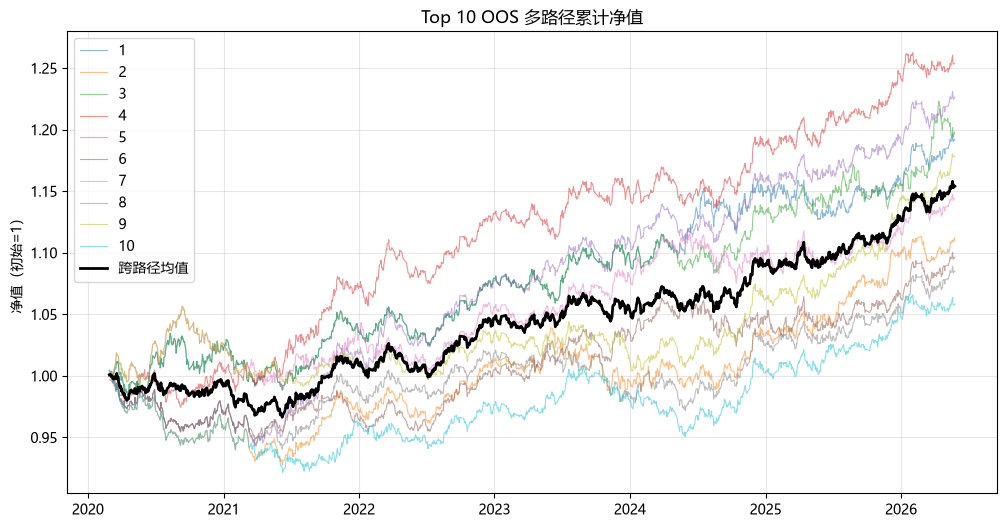

In [68]:
top_k_mpts = Population([mpt for mpt in eval_ctrl['mpts'].values()])
plot_paths_curve(top_k_mpts, title='Top 10 OOS 多路径累计净值', labels=[k for k in eval_['mpts'].keys()])

### Ensemble

In [69]:
from wf_topk_ensemble import topk_ensemble_eval

In [ ]:
real_ens = topk_ensemble_eval(X, fold_real, k=10) 
fake_ens = topk_ensemble_eval(X_fake, fold_real, k=10) 
ctrl_ens = topk_ensemble_eval(X_ctrl, fold_real, k=10) 

Fold 0: 候选=10 | top1资产=7 | 融合池=10（重叠=7）| top1_test=1.0364 | ens_test=1.4121
Fold 1: 候选=10 | top1资产=8 | 融合池=17（重叠=8）| top1_test=0.9188 | ens_test=1.2478
Fold 2: 候选=10 | top1资产=6 | 融合池=9（重叠=6）| top1_test=0.2923 | ens_test=0.5441
Fold 3: 候选=10 | top1资产=6 | 融合池=11（重叠=6）| top1_test=1.4719 | ens_test=1.0252
Fold 4: 候选=10 | top1资产=4 | 融合池=16（重叠=4）| top1_test=1.5844 | ens_test=1.0591
Fold 5: 候选=10 | top1资产=5 | 融合池=14（重叠=5）| top1_test=1.8458 | ens_test=1.7185
完整 OOS 路径: 6 折拼接, 共 1512 天
Fold 0: 候选=10 | top1资产=59 | 融合池=60（重叠=59）| top1_test=1.4700 | ens_test=1.4280
Fold 1: 候选=10 | top1资产=50 | 融合池=73（重叠=50）| top1_test=0.4360 | ens_test=0.3467
Fold 2: 候选=10 | top1资产=29 | 融合池=62（重叠=29）| top1_test=0.8100 | ens_test=-0.0274
Fold 3: 候选=10 | top1资产=25 | 融合池=45（重叠=25）| top1_test=0.6394 | ens_test=0.8379
Fold 4: 候选=10 | top1资产=14 | 融合池=17（重叠=14）| top1_test=0.7074 | ens_test=0.5432
Fold 5: 候选=10 | top1资产=23 | 融合池=54（重叠=23）| top1_test=0.8481 | ens_test=1.0551
完整 OOS 路径: 6 折拼接, 共 1512 天


NameError: name 'fold_ctrl' is not defined

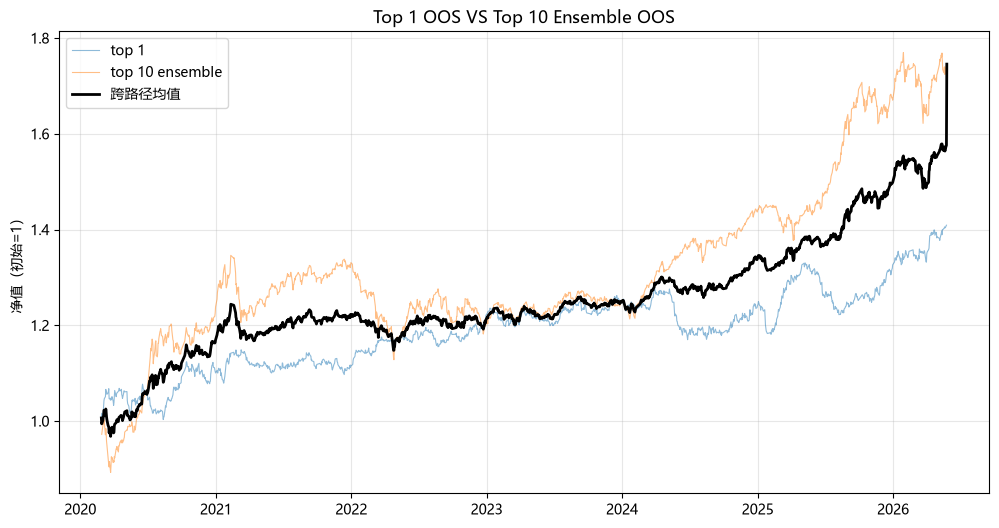

In [74]:
ensemble_mpt = Population([fake_ens['paths']['top1'], ens['paths']['ensemble']])
plot_paths_curve(ensemble_mpt, title='Top 1 OOS VS Top 10 Ensemble OOS', labels=['top 1','top 10 ensemble'])

In [ ]:
#log_print(ens['paths']['ensemble'].summary(),section='Top 10 Ensemble OSS Summary',echo=False)

### Step 4｜单参数敏感性曲线
- 每折只动目标参数、其余保持生产值（fitness 固定 top1）；`frac=0` 档即生产值本身（锚点）。
- 默认覆盖**全部数值参数含 `train_size`**（它是搜索维度之一，扰动后评估即用扰动后的拟合窗口长度）。
- 读图：参数高原 = ±30% 内绩效平缓；孤峰 = 仅生产值附近突出（与 IS 侧 gap2top1 互证）。
- 只评估单折 OOS → 无 CPCV 展开，成本低，可全参数全档位跑。

Fold 0: 单参网格完成 (5 参数 × 6 档)
Fold 1: 单参网格完成 (5 参数 × 6 档)
Fold 2: 单参网格完成 (5 参数 × 6 档)
Fold 3: 单参网格完成 (5 参数 × 6 档)
Fold 4: 单参网格完成 (5 参数 × 6 档)
Fold 5: 单参网格完成 (5 参数 × 6 档)


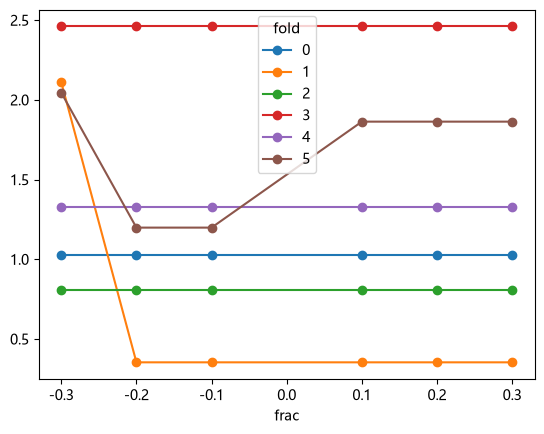

In [75]:
curves = sensitivity_curves(X, fold_real, reduce_test=False)             # 默认 ±10/20/30% 六档 × 全部数值参数
c = curves[curves["param"] == "extremes__k"]
ax = c.pivot_table(index="frac", columns="fold",
                   values="annualized_sharpe_ratio").plot(marker="o")
plt.show()

### Step 5｜双参数联合热力图（checklist 4.2）

- 返回 `{fold: DataFrame(index=frac_a, columns=frac_b), "mean": 跨折逐格平均}`。
- 读图：各档平缓 → 联合高原（稳健）；仅 (0,0) 突出 → 联合孤峰（脆弱）；
  对角陡峭 → 两参数互补/冲突（交互项存在）。

Fold 0: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 1: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 2: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 3: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 4: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 5: extremes__k×correlate__threshold 热力图 (5×5) 完成


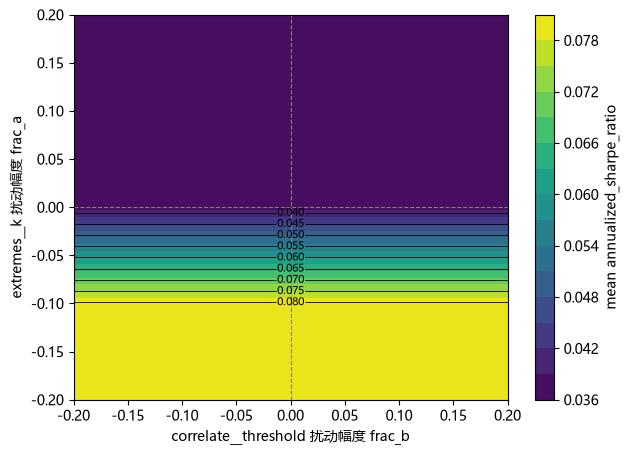

In [77]:
import numpy as np
import matplotlib.pyplot as plt

grids = sensitivity_heatmap(X_fake, fold_real, param_a="extremes__k",
                            param_b="correlate__threshold",
                            reduce_test=False)
mean = grids["mean"]                          # 行=frac_a, 列=frac_b, 值=跨折平均ASR
Xg, Yg = np.meshgrid(mean.columns, mean.index)   # x=frac_b, y=frac_a，与 values[i,j] 对齐
fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(Xg, Yg, mean.values, levels=15, cmap="viridis")   # 彩色填充
cs = ax.contour(Xg, Yg, mean.values, levels=8, colors="k", linewidths=0.6)  # 等值线
ax.clabel(cs, inline=True, fontsize=8)        # 标数值
ax.axhline(0, color="gray", lw=0.8, ls="--")  # 生产值锚点十字线（0,0 = 未扰动）
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("correlate__threshold 扰动幅度 frac_b")
ax.set_ylabel("extremes__k 扰动幅度 frac_a")
fig.colorbar(cf, label="mean annualized_sharpe_ratio")
plt.show()

### Step 6｜消融实验

- 臂：`full`（基准）/ `no_extremes` / `no_nondomin` / `no_correlate` / `no_extremes_correlate`。
- 每臂 = 固定每折最优参数 × 剔除对应管线步骤 × CPCV 多路径压测（同窗同口径对比）。
- 判读：全臂样本路径数一致（每折 = `n_test_folds` 组合路径），绩效差距即模块边际贡献；
  某模块剔除后绩效**不降反升** → 该模块负贡献，考虑剔除后重搜（会作废旧 OOS）。

In [81]:
frames, summary = ablate(X_ctrl, fold_real)                # arms=None = 全部 5 臂
summary

,说明,折数,天数,annualized_mean,annualized_sharpe_ratio,max_drawdown,skew,kurtosis
臂,,,,,,,,
full,全管线（基准）,6,1512,0.030010,0.764587,0.044809,0.018242,3.668385
no_extremes,无峰度预筛（剔除 extremes 步骤）,6,1512,0.028433,0.834426,0.058737,-0.032984,3.239304
no_nondomin,无非支配筛选（剔除 nondomin 步骤）,6,1512,0.020422,0.560419,0.063505,-0.034218,3.661891
no_correlate,无去相关（剔除 correlate 步骤）,6,1512,0.000721,0.011319,0.146531,0.178449,4.355329
no_extremes_correlate,剔除 extremes + correlate,6,1512,-0.000711,-0.012599,0.147109,0.160187,3.886800


In [29]:
log_result(summary.to_string(), section="消融实验")

### Step 7｜参数扰动蒙特卡洛 + 判定

In [ ]:
out = perturbation_mc(X, fold_results, fitness_topk=5)                   # R=None → ceil(500 / 折数)，总样本 ≥ 500

In [ ]:
out['verdict']

In [ ]:
out['fold_summary']

In [79]:
oos_pop = Population([fold['test'] for fold in fold_real])
oos_pop.plot_cumulative_returns()

In [82]:
oos_mpt = MultiPeriodPortfolio([fold['test'] for fold in fold_real],compounded=True)
oos_mpt.plot_cumulative_returns()

#### 路径采样

In [83]:
fold_paths = adaptive_multi_paths(X, fold_real, 
                                 test_size=search_params['test_size'], 
                                 train_size=search_params['train_size'],
                                 n_test_folds=search_params['n_test_folds'], n_jobs=8)

Fold 0: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 1: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 2: paths=5 | window=756 | inner_folds=6 | test_days=252
Fold 3: paths=5 | window=756 | inner_folds=6 | test_days=252
Fold 4: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 5: paths=7 | window=1008 | inner_folds=8 | test_days=252


In [84]:
oos_blocks = build_test_parts(fold_paths, n_test_folds=search_params['n_test_folds'])
oos_paths = discrete_lhs_safe(oos_blocks, n_samples=1000, seed=42)
oos_mpts = Population([MultiPeriodPortfolio(path ,compounded=False) for path in oos_paths])

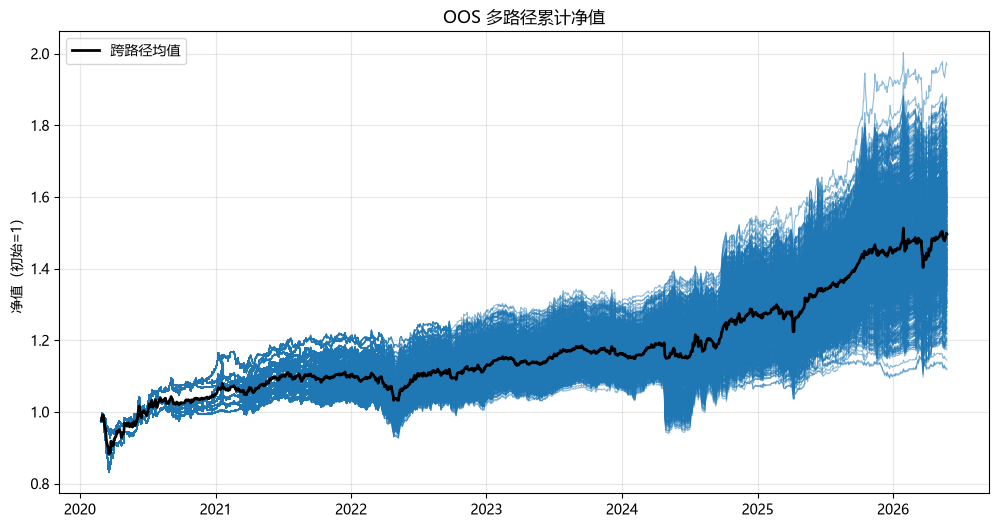

In [85]:
plot_paths_curve(oos_mpts)

In [35]:
log_print(oos_mpt.summary(),section='OSS Summary',echo=False)

### OOS诊断：
- Annualized Mean 分布
- PSR诊断
- 基准联动
- 换手频率

LHS多路径分布(1000条): 均值 0.0710 | 中位 0.0706 | 5% 0.0474 | 95% 0.0944
WF真实路径: 0.1033 | 分布中 2.20σ | 分位 98.8%


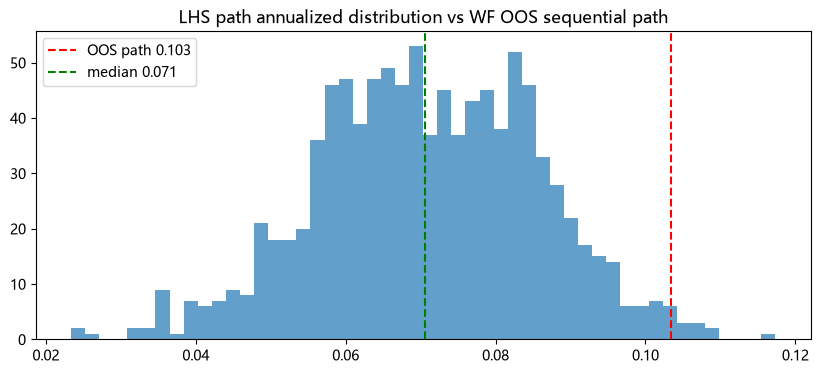

In [86]:
# 年化分布
path_anns = np.array([oos_mpt.annualized_mean for oos_mpt in oos_mpts])

oos_ann = oos_mpt.annualized_mean

report_ann_distribution(path_anns, oos_ann)

In [87]:
diagnose_result = diagnose_oos_lhs(lhs_paths=oos_paths)
del diagnose_result['mc_sharpes']
del diagnose_result['mc_mdds']
del diagnose_result['mc_psrs']
log_print(diagnose_result, section='OOS PSR Diagnose',echo=False)

[Info] 1000 LHS paths | OOS 1512 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 0.00%
  ✅ Sharpe 90% CI         : [0.271, 0.840]
  ✅ MDD median / worst-5%  : 13.72% / 17.88%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 0.5451
  ⚠️ PSR(0) median / 5%    : 100.00% / 100.00%


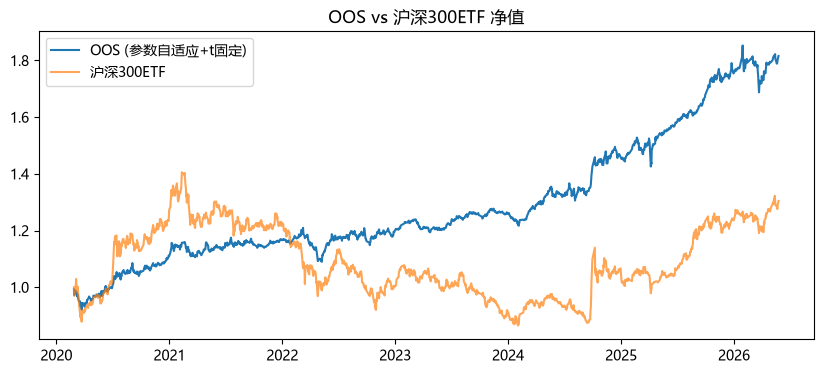

In [88]:
plot_oos_vs_bench(oos_mpt, bench_ret)

In [39]:

df_ex = excess_vs_bench(oos_mpts, bench_ret)
log_result(df_ex.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%", "mean"]].round(4),
           section="OOS vs 沪深300 相对收益分布")

      ann_excess  arith_excess      IR  winrate
5%        0.0400        0.0293  0.1929   0.5192
50%       0.0770        0.0680  0.4487   0.5298
95%       0.1146        0.1074  0.6623   0.5417
mean      0.0770        0.0680  0.4388   0.5301


### 模拟+双向参数迁移验证
（Bidirectional Parameter Transfer Validation）
```python
# 1）可选传基准供画图：simulate_sl(..., bench=bench_ret)，结果在 res["bench"]
cmp_tbl = summarize_sl(res, base)
# 2) 落盘（与既有 log_result 体系一致）
log_result(cmp_tbl,         section="SL模拟 vs 无止损基线")
log_result(res["epochs"],   section="SL 模拟 epoch 明细")
log_result(res["triggers"], section="SL 触发明细")
```

In [28]:
from sl_simulation import load_sl_config, simulate_sl, summarize_sl

In [29]:
cfg  = load_sl_config()
cfg['space'] = search_space
cfg['search_kwargs'] = search_params

In [ ]:
oos = simulate_sl(X, folds=fold_real, cfg=cfg, conditions=[])

In [ ]:
fake = simulate_sl(X, folds=fold_fake, cfg=cfg, conditions=[])

Epoch 0: 2020-02-27 -> 2021-03-10 (252d, expired) | src=fold_reuse | ASR=1.414 | 累计=17.83%
Epoch 1: 2021-03-11 -> 2022-03-23 (252d, expired) | src=fold_reuse | ASR=1.162 | 累计=11.00%
Epoch 2: 2022-03-24 -> 2023-04-06 (252d, expired) | src=fold_reuse | ASR=0.931 | 累计=9.11%
Epoch 3: 2023-04-07 -> 2024-04-22 (252d, expired) | src=fold_reuse | ASR=1.522 | 累计=7.96%
Epoch 4: 2024-04-23 -> 2025-05-09 (252d, expired) | src=fold_reuse | ASR=0.932 | 累计=11.37%
Epoch 5: 2025-05-12 -> 2026-05-25 (252d, expired) | src=fold_reuse | ASR=2.618 | 累计=35.96%
决策日 2026-05-25: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 6: 2026-05-26 -> 2026-09-18 (83d, end_of_data) | src=fresh | ASR=0.949 | 累计=5.35%


In [ ]:
ctrl  = simulate_sl(X, folds=fold_ctrl, cfg=cfg, conditions=[])

Epoch 0: 2020-02-27 -> 2021-03-10 (252d, expired) | src=fold_reuse | ASR=-0.461 | 累计=-3.52%
Epoch 1: 2021-03-11 -> 2022-03-23 (252d, expired) | src=fold_reuse | ASR=2.438 | 累计=9.63%
Epoch 2: 2022-03-24 -> 2023-04-06 (252d, expired) | src=fold_reuse | ASR=2.906 | 累计=13.07%
Epoch 3: 2023-04-07 -> 2024-04-22 (252d, expired) | src=fold_reuse | ASR=2.319 | 累计=17.81%
Epoch 4: 2024-04-23 -> 2025-05-09 (252d, expired) | src=fold_reuse | ASR=0.124 | 累计=0.41%
Epoch 5: 2025-05-12 -> 2026-05-25 (252d, expired) | src=fold_reuse | ASR=2.143 | 累计=11.09%
决策日 2026-05-25: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 6: 2026-05-26 -> 2026-09-18 (83d, end_of_data) | src=fresh | ASR=-0.427 | 累计=-0.95%


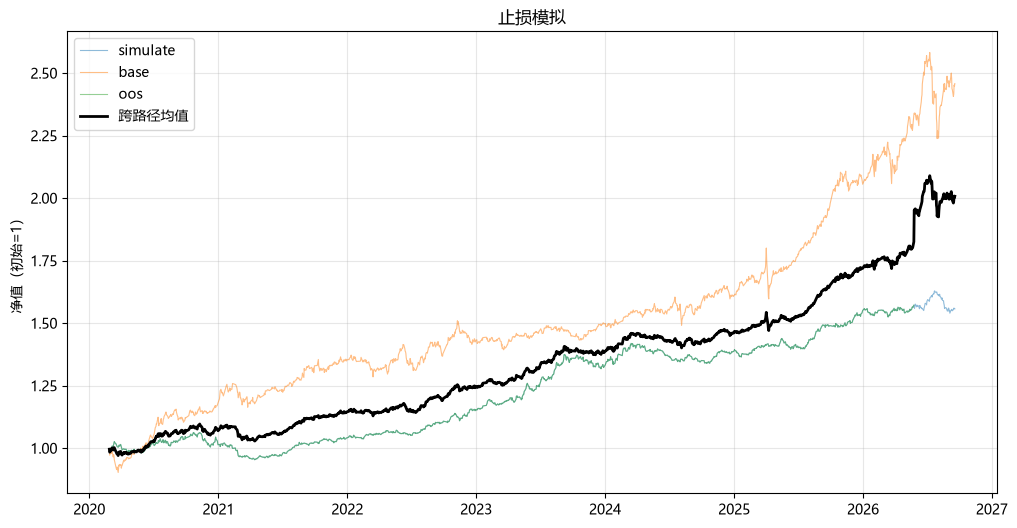

In [44]:
sl_mpts = Population([res['mpt'], base['mpt'], oos_mpt])
plot_paths_curve(sl_mpts, title='止损模拟', labels=['simulate','base', 'oos'])

In [ ]:
for pf in res['legs']:
    print(pf.assets)

### Fresh CPCV

In [ ]:
cfg = load_sl_config(); cfg['space'] = search_space; cfg['search_kwargs'] = search_params
X_cut = X.tail(search_params['train_size'] + 1)      # 搜索窗口 + 1 天建仓日
final = simulate_sl(X_cut, cfg=cfg, conditions=[])   # 不传 folds → 全程 fresh；conditions=[] 纯搜索
# 参数记录: final['searches']  |  建仓头寸: final['legs'][0].weights / .assets

决策日 2026-09-17: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0: 2026-09-18 -> 2026-09-18 (1d, end_of_data) | src=fresh | ASR=nan | 累计=0.52%


In [81]:
final['mpt'].assets

[array(['161115.SZ', '161127.SZ', '501046.SH', '511270.SH', '515150.SH',
        '516310.SH'], dtype=object)]

In [ ]:
[array(['160611.SZ', '163409.SZ', '501046.SH', '511270.SH', '513000.SH',
        '515020.SH', '560780.SH'], dtype=object)]
[array(['161115.SZ', '161127.SZ', '161128.SZ', '501046.SH', '501087.SH',
        '511270.SH', '515150.SH', '516310.SH', '560780.SH'], dtype=object)]

In [46]:
X_cut = X_ctrl.tail(search_params['train_size'] + 1)      # 搜索窗口 + 1 天建仓日
final = simulate_sl(X_cut, cfg=cfg, conditions=[])
final['mpt'].assets

决策日 2026-09-17: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0: 2026-09-18 -> 2026-09-18 (1d, end_of_data) | src=fresh | ASR=nan | 累计=0.48%


[array(['159207.SZ', '160643.SZ', '160722.SZ', '161039.SZ', '161119.SZ',
        '163907.SZ', '164210.SZ', '164808.SZ', '166009.SZ', '168105.SZ',
        '169106.SZ', '180701.SZ', '501038.SH', '501202.SH', '508011.SH',
        '508033.SH', '508098.SH', '511520.SH', '515450.SH', '518860.SH',
        '560880.SH'], dtype=object)]

In [52]:
# 单轮（实盘前最后一次搜索）场景：
rec   = next(iter(final["searches"].values()))
study = rec["study"]          # ← optuna Study 对象，trial 级全历史：trial.params / trial.value / trial.state

# 直接喂给体系里消费 study 的函数：
from cpcv_analysis import empirical_deflate, top_trials
d     = empirical_deflate(study)            # margin / max_p95 / n_trials_total 全套（从 study 现算，无重算搜索）
cands = top_trials(study.trials, k=10)      # Top-K 候选

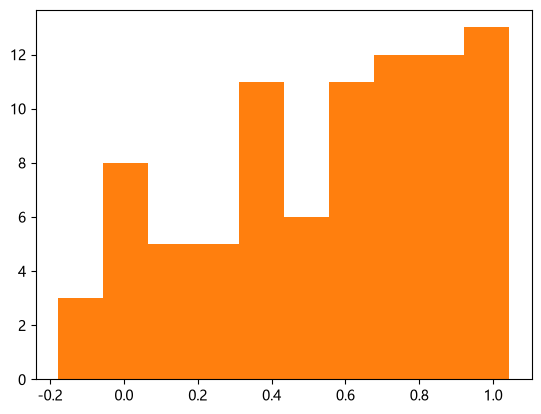

In [54]:
plt.hist(d['scores'])
plt.show()

### 双向参数迁移验证”（Bidirectional Parameter Transfer Validation）